# Opay Review Sentiment Classifier: RF vs BERT

In [77]:
# Connecting Google Drive with Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
# Importing essential libraries
import numpy as np
import pandas as pd

In [79]:

# Loading the dataset
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Opay Review Sentiment Classifier/opay_reviews.csv')

## Exploring the dataset

In [80]:
df.shape

(10001, 12)

In [81]:
df.head()

,review_id,author,score,sentiment_from_stars,text,thumbs_up,date,app_version,reply_content,country,lang,sort
0,7c3568b1-ce45-4b81-8ec1-80ef5bebbcad,Suleiman Nasir,5,positive,"very easy to operate, And safety.",0,2026-09-15 15:06:36,8.16.0.491,"Hi, @Suleiman Nasir. Amazing feedback 😍! We ar...",ng,en,NEWEST
1,309b9e8c-7d39-4f9e-b132-9c462f5fe9e5,Darlington Ifeanyi Anoruo,5,positive,"I love this app, transactions are smooth and f...",0,2026-09-15 15:06:35,8.14.1.485,"Hi, @Darlington Ifeanyi Anoruo. Thank you so m...",ng,en,NEWEST
2,95398023-cee4-4141-b2e0-9e8e55311f76,Bryan Coco-Bassey,4,positive,smooth and seamless,0,2026-09-15 15:03:28,8.16.0.491,"Hi, @Bryan Coco-Bassey. Thank you for your pos...",ng,en,NEWEST
3,c1ff8501-414f-45be-adb3-8f81d221074f,Samuel Christopher,5,positive,I love opay so much to be honest Opay is the b...,0,2026-09-15 15:03:26,8.17.1.493,"Hi, @Samuel Christopher. Thank you so much for...",ng,en,NEWEST
4,24706612-0d45-4df6-8b31-672d34a97a5d,Kamsi Christian Anayo,5,positive,love the app,0,2026-09-15 15:00:28,8.17.1.493,"Hi, @Kamsi Christian Anayo. We’re thrilled tha...",ng,en,NEWEST


In [82]:
df["text"].sample(5)

,text
1127,fast and reliable
3272,I need the opay
9203,"Quite an interesting app, but they are not tru..."
6046,simple illustration reliable and efficient ser...
296,beautiful


In [83]:
df['sentiment_from_stars'].value_counts()

,count
sentiment_from_stars,
positive,7454
negative,1945
neutral,602


In [84]:
# Importing essential libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

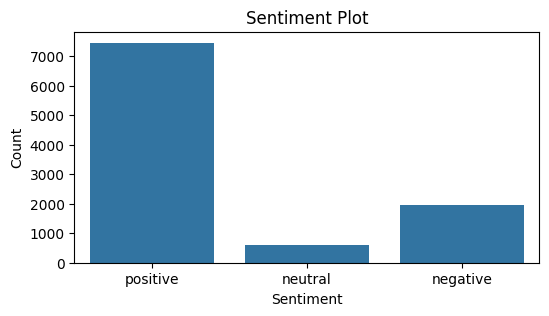

In [85]:
# Visualizing the count of 'sentiment_from_stars' column from the dataset
plt.figure(figsize=(6,3))
sns.countplot(x='sentiment_from_stars', data=df)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Plot')
plt.show()

## Data Cleaning and Preprocessing

In [86]:
# Finding any NaN values
df.isna().any()

,0
review_id,False
author,False
score,False
sentiment_from_stars,False
text,False
thumbs_up,False
date,False
app_version,True
reply_content,True
country,False


In [87]:
# Importing essential libraries for performing NLP
import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

wnl = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [88]:
def preprocessor(text):
    # change text to lower case
    text = text.lower()
    # Cleaning special character
    text = re.sub(pattern='[^a-zA-Z0-9]', repl=' ', string=text)
    # Tokenizing the sms by words
    text = text.split()

    # Removing the stop words
    filtered_words = [word for word in text if word not in set(stopwords.words('english'))]

    # Lemmatizing the words
    lemmatized_words = [wnl.lemmatize(word) for word in filtered_words]

    # Joining the lemmatized words
    return ' '.join(lemmatized_words)

In [89]:
#text cleaning
df["clean_text"]=df["text"].apply(preprocessor)

In [90]:
X=df["clean_text"]
y=df["sentiment_from_stars"]

In [91]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [92]:
#Split the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [93]:
# Creating the Bag of Words model
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Model Building & Evaluation For RandomForest

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [95]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

labels = df["sentiment_from_stars"]
classes = np.unique(labels)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)

weight_dict = dict(zip(classes, class_weights))
print(weight_dict)

{'negative': np.float64(1.7139674378748928), 'neutral': np.float64(5.53765227021041), 'positive': np.float64(0.447231911278061)}


In [96]:
rf = RandomForestClassifier(n_estimators=300, class_weight=weight_dict, n_jobs=-1, random_state=42)

In [97]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # <-- automatically weights inversely to class frequency
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [129]:
#Save RandomForest model
import joblib

joblib.dump(rf, '/content/drive/My Drive/Colab Notebooks/Opay Review Sentiment Classifier/rf_sentiment_model.pkl')
joblib.dump(vectorizer, '/content/drive/My Drive/Colab Notebooks/Opay Review Sentiment Classifier/tfidf_vectorizer.pkl')
joblib.dump(encoder, '/content/drive/My Drive/Colab Notebooks/Opay Review Sentiment Classifier/label_encoder.pkl')

['/content/drive/My Drive/Colab Notebooks/Opay Review Sentiment Classifier/label_encoder.pkl']

In [98]:
#Evaluate
y_pred = rf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.65      0.67       389
           1       0.13      0.06      0.08       121
           2       0.87      0.92      0.89      1491

    accuracy                           0.82      2001
   macro avg       0.57      0.54      0.55      2001
weighted avg       0.79      0.82      0.80      2001

[[ 253    3  133]
 [  38    7   76]
 [  70   45 1376]]


## Model Building & Evaluation for BERT

In [99]:
#We will do small cleaning on the text column
import re

def clean(text):
    text = text.lower()

    # remove emojis (broad unicode ranges covering most emoji blocks)
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U0001F900-\U0001F9FF"
        "\U00002600-\U000026FF"
        "\U0001FA70-\U0001FAFF"
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub("", text)

    # remove punctuation/special characters, keep letters, numbers, spaces
    text = re.sub(r"[^a-z0-9\s]", "", text)

    tokens = text.split()
    return " ".join(tokens)

text = df["text"].apply(clean).values

Text(0.5, 1.0, 'Number of sentences')

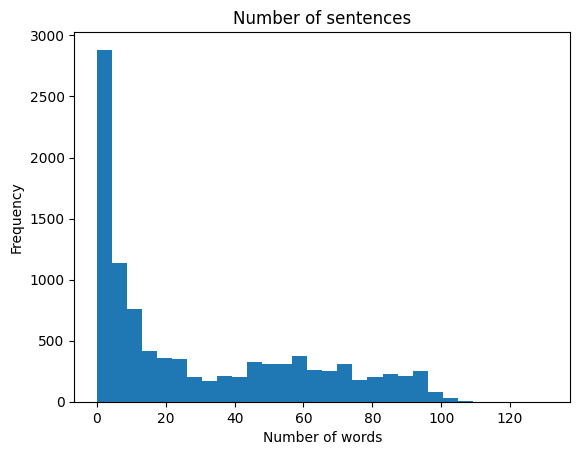

In [100]:
#compute the No of words in each text
import matplotlib.pyplot as plt
num=[len(i.split()) for i in text]
plt.hist(num,bins=30)
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.title("Number of sentences")

In [101]:
#Loading BERT pre-trained model
from transformers import BertModel
bert=BertModel.from_pretrained('bert-base-uncased')
#Import BERT Tokenizer
from transformers import BertTokenizerFast
tokenizer = tokenizer=BertTokenizerFast.from_pretrained('bert-base-uncased',do_lower_case=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [102]:
max_length=30

In [103]:
from tqdm import notebook
#create empty list to save integer sequence
sent_id=[]
#iterate over each tweet
for i in notebook.tqdm(range(len(text))):

  encoded_sent=tokenizer.encode(text[i],
                                add_special_tokens=True,
                                max_length=max_length,
                                truncation=True,
                                padding="max_length")
  sent_id.append(encoded_sent)


  0%|          | 0/10001 [00:00<?, ?it/s]

In [104]:
print("Integer Sequence: ",sent_id[1])

Integer Sequence:  [101, 1045, 2293, 2023, 10439, 11817, 2024, 5744, 1998, 3435, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [105]:
#create attention mask
attention_mask=[]

for sent in sent_id:
  att=[int(token>0) for token in sent]
  attention_mask.append(att)

#Training and Validation Data

In [106]:
#Same test size as RandomForest
import torch
#Use 80% for training and 20% for validation
train_inputs,validation_inputs,train_labels,validation_labels=train_test_split(sent_id,y,test_size=0.2,random_state=42,stratify=y)

#Do the same thing for mask
train_masks,validation_masks,_,_=train_test_split(attention_mask,y,test_size=0.2,random_state=42,stratify=y)

#Convert all inputs and labels to torch tensor
train_inputs=torch.tensor(train_inputs)
validation_inputs=torch.tensor(validation_inputs)

train_labels=torch.tensor(train_labels)
validation_labels=torch.tensor(validation_labels)

train_masks=torch.tensor(train_masks)
validation_masks=torch.tensor(validation_masks)

In [107]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

#define a batch size
batch_size = 16

# Create the DataLoader for our training set.
#Dataset wrapping tensors.
train_data = TensorDataset(train_inputs, train_masks, train_labels)

#define a sampler for sampling the data during training
  #random sampler samples randomly from a dataset
  #sequential sampler samples sequentially, always in the same order
train_sampler = RandomSampler(train_data)

#represents an iterator over a dataset. Supports batching, customized data loading order
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

# Create the DataLoader for our validation set.
#Dataset wrapping tensors.
validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)

#define a sequential sampler
#This samples data in a sequential order
validation_sampler = SequentialSampler(validation_data)

#create a iterator over the dataset
validation_dataloader = DataLoader(validation_data, sampler=validation_sampler, batch_size=batch_size)

In [108]:
#loads batch data
sent_id, mask, target = next(iter(train_dataloader))

In [109]:
#pass inputs to the model
outputs = bert(sent_id,              #integer sequence
                attention_mask=mask) #attention masks

In [110]:
# hidden states
hidden_states = outputs[0]

# [CLS] hidden state
CLS_hidden_state = outputs[1]

print("Shape of Hidden States:",hidden_states.shape)
print("Shape of CLS Hidden State:",CLS_hidden_state.shape)

Shape of Hidden States: torch.Size([16, 30, 768])
Shape of CLS Hidden State: torch.Size([16, 768])


In [111]:
# turn off the gradient of all the parameters
for param in bert.parameters():
    param.requires_grad = False

In [112]:
import torch.nn as nn

class classifier(nn.Module):

    #define the layers and wrappers used by model
    def __init__(self, bert):

        #constructor
        super(classifier, self).__init__()

        #bert model
        self.bert = bert

        # dense layer 1
        self.fc1 = nn.Linear(768,512)

        #dense layer 2 (Output layer)
        self.fc2 = nn.Linear(512,3)

        #dropout layer
        self.dropout = nn.Dropout(0.1)

        #relu activation function
        self.relu =  nn.ReLU()

        #softmax activation function
        self.softmax = nn.LogSoftmax(dim=1)

    #define the forward pass
    def forward(self, sent_id, mask):

      #pass the inputs to the model
      outputs = self.bert(sent_id, attention_mask=mask)

      # Accessing outputs by attributes (last_hidden_state and pooler_output) for robustness
      all_hidden_states = outputs.last_hidden_state
      cls_hidden_state = outputs.pooler_output

      #pass CLS hidden state to dense layer
      x = self.fc1(cls_hidden_state)

      #Apply ReLU activation function
      x = self.relu(x)

      #Apply Dropout
      x = self.dropout(x)

      #pass input to the output layer
      x = self.fc2(x)

      #apply softmax activation
      x = self.softmax(x)

      return x

In [113]:
#create the model
model = classifier(bert)
print(model)

classifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine

In [114]:
# pass inputs to the model
output=model(sent_id,mask)


In [115]:
# understand outputs
print(output)

tensor([[-1.0747, -1.3464, -0.9202],
        [-1.1043, -1.3390, -0.9003],
        [-0.9565, -1.2800, -1.0856],
        [-1.0336, -1.3744, -0.9383],
        [-1.0503, -1.4046, -0.9046],
        [-1.0918, -1.3893, -0.8792],
        [-1.0321, -1.3702, -0.9424],
        [-1.0246, -1.3425, -0.9679],
        [-1.1163, -1.3439, -0.8874],
        [-1.0396, -1.3421, -0.9542],
        [-1.0143, -1.4441, -0.9129],
        [-1.0932, -1.3897, -0.8778],
        [-1.0338, -1.4171, -0.9115],
        [-1.0338, -1.4388, -0.8986],
        [-0.9790, -1.4716, -0.9295],
        [-0.9436, -1.3862, -1.0196]], grad_fn=<LogSoftmaxBackward0>)


In [116]:
# no. of trianable parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 395,267 trainable parameters


In [117]:
# converting a list of class weights to a tensor
weights= torch.tensor(class_weights,dtype=torch.float)

# define the loss function
cross_entropy  = nn.NLLLoss(weight=weights)

In [118]:
#compute the loss
loss = cross_entropy(output, target)
print("Loss:",loss)

Loss: tensor(1.0142, grad_fn=<NllLossBackward0>)


In [119]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
weights = weights.to(device)
cross_entropy = nn.NLLLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train():
    model.train()
    total_loss = 0
    all_preds = []

    for step, batch in enumerate(train_dataloader):
        sent_id, mask, labels = [b.to(device) for b in batch]

        model.zero_grad()

        preds = model(sent_id, mask)
        loss = cross_entropy(preds, labels)

        total_loss += loss.item()
        loss.backward()

        # prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        preds = preds.detach().cpu().numpy()
        all_preds.append(preds)

    avg_loss = total_loss / len(train_dataloader)
    all_preds = np.concatenate(all_preds, axis=0)
    return avg_loss, all_preds


def evaluate():
    model.eval()
    total_loss = 0
    all_preds = []

    for step, batch in enumerate(validation_dataloader):
        sent_id, mask, labels = [b.to(device) for b in batch]

        with torch.no_grad():
            preds = model(sent_id, mask)
            loss = cross_entropy(preds, labels)
            total_loss += loss.item()

            preds = preds.detach().cpu().numpy()
            all_preds.append(preds)

    avg_loss = total_loss / len(validation_dataloader)
    all_preds = np.concatenate(all_preds, axis=0)
    return avg_loss, all_preds

In [120]:
num = [len(i.split()) for i in text]
print(np.percentile(num, [50, 90, 95, 99]))

[15. 79. 89. 97.]


In [121]:
epochs = 5
best_valid_loss = float('inf')

for epoch in range(epochs):
    print(f'\nEpoch {epoch + 1} / {epochs}')

    train_loss, _ = train()
    valid_loss, valid_preds = evaluate()

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), '/content/drive/My Drive/Colab Notebooks/Opay Review Sentiment Classifier/best_model.pt')

    print(f'Training Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')


_, final_preds = evaluate()
final_preds = np.argmax(final_preds, axis=1)
print(classification_report(validation_labels.numpy(), final_preds))


Epoch 1 / 5
Training Loss: 1.011
Validation Loss: 1.043

Epoch 2 / 5
Training Loss: 0.946
Validation Loss: 1.000

Epoch 3 / 5
Training Loss: 0.913
Validation Loss: 0.876

Epoch 4 / 5
Training Loss: 0.900
Validation Loss: 0.868

Epoch 5 / 5
Training Loss: 0.910
Validation Loss: 0.865
              precision    recall  f1-score   support

           0       0.53      0.85      0.65       389
           1       0.25      0.01      0.02       121
           2       0.93      0.85      0.89      1491

    accuracy                           0.80      2001
   macro avg       0.57      0.57      0.52      2001
weighted avg       0.81      0.80      0.79      2001



In [ ]:
# Load best model and get final report
model.load_state_dict(torch.load('/content/drive/My Drive/Colab Notebooks/Opay Review Sentiment Classifier/best_model.pt'))

In [123]:
# Converting the log(probabities) into a classes
# Choosing index of a maximum value as class
_, final_preds = evaluate()
final_preds = np.argmax(final_preds, axis=1)
print(classification_report(validation_labels.numpy(), final_preds))

              precision    recall  f1-score   support

           0       0.53      0.85      0.65       389
           1       0.25      0.01      0.02       121
           2       0.93      0.85      0.89      1491

    accuracy                           0.80      2001
   macro avg       0.57      0.57      0.52      2001
weighted avg       0.81      0.80      0.79      2001

